## Overview

This notebook builds a synthetic multi-asset portfolio with a known ground truth. The point is to have something where I know the *true* underlying price dynamics, so I can check whether the Kalman filter is actually recovering that signal before trusting it on real financial data.

Four correlated assets, each with its own drift and volatility:

| Ticker | Description                      | Drift (μ) | Volatility (σ) |
|--------|-----------------------------------|-----------|-----------------|
| EQTY   | SP500 tracker                    | 0.07      | 0.18            |
| BOND   | TST American Bonds                    | 0.03      | 0.05            |
| GOLD   | Gold EFT              | 0.02      | 0.15            |
| TECH   | Nasdaq 100  | 0.12      | 0.35            |

Prices are simulated as correlated geometric Brownian motion, with the correlation imposed via a Cholesky decomposition.

Once the filter is tuned against this known ground truth, we test it against real ETF data (SPY/TLT/GLD/QQQ) later in the notebook.

I won't bother with EU/Norwegian stocks because the tickers are too long and complicated when using the yfinance library.

In [31]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from dataclasses import dataclass

import sys
sys.path.append("../src")

# This file contains code that helps me create
# market data based on imposed values
from simulate_gbm_market import Asset, simulate_gbm_market

In [32]:
# Definition of assets
# mu being expected returns and sigma being volatility
assets = [
    Asset("EQTY", mu=0.07, sigma=0.18),
    Asset("BOND", mu=0.03, sigma=0.05),
    Asset("GOLD", mu=0.02, sigma=0.15),
    Asset("TECH", mu=0.12, sigma=0.35),
]

# We create a correlation matrix, as a standard equity portfolio will have significant overlap with tech    
corr = np.array([
    [1.00,  -0.30, 0.05, 0.55],
    [-0.30,  1.00, 0.10, -0.25],
    [0.05,   0.10, 1.00, 0.00],
    [0.55,  -0.25, 0.00, 1.00],
])

# We create starting values for our simulation, indexing everything to 100
s0 = np.array([100, 100, 100, 100])

Now that we have initial conditions set up we create a function that let's us simulate a market using brownian motion
Having done some research I know the best way to make them correlate with eachother is to go take a second look on cholesky decompositions

In [33]:
# Simulates correlated geometric Brownian Motion for N assets.
# Each asset gets assigned a drift and a volatility
# Correlation imposed using cholesky

# Run it
prices = simulate_gbm_market(assets, corr, s0, n_days=1000, seed=None)
prices.head()

,EQTY,BOND,GOLD,TECH
2023-01-02,99.082386,99.918414,100.576577,99.881143
2023-01-03,98.789433,100.335881,99.639806,100.309657
2023-01-04,98.587205,100.168993,98.167449,100.163259
2023-01-05,98.424851,99.909302,96.675430,100.022398
2023-01-06,99.145123,99.374744,96.304922,101.970167


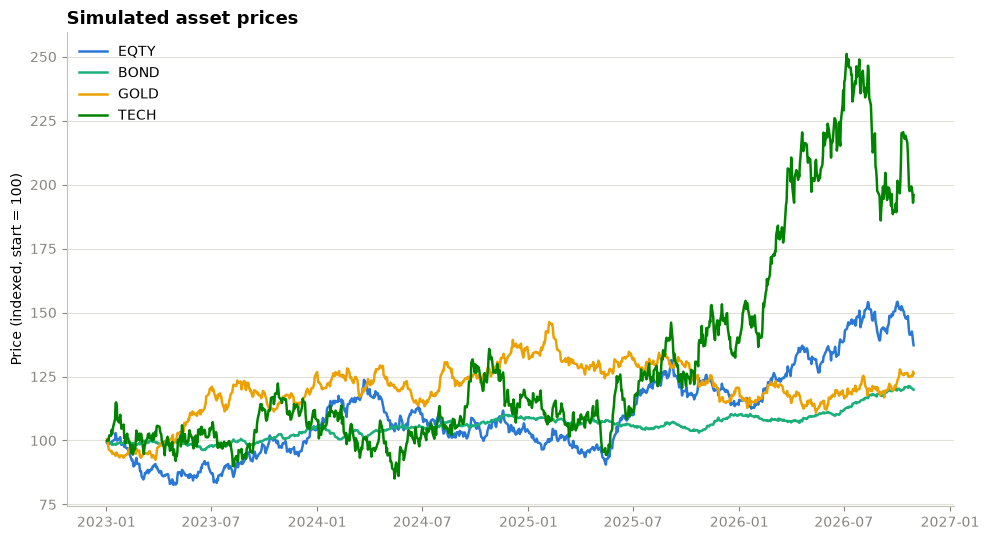

In [34]:
# Claude fixes displaying the graphs, no idea how this works

COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#008300"]

fig, ax = plt.subplots(figsize=(10, 5.5))

for ticker, color in zip(prices.columns, COLORS):
    ax.plot(prices.index, prices[ticker], color=color, linewidth=1.8, label=ticker)

ax.set_title("Simulated asset prices", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Price (indexed, start = 100)")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")

ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#898781")

ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

**We now have a reliable way to simulate the markets from from our known outputs**
The next step is to make a Kalman filter to retrive the underlying data

**Because we know the actual underlying characteristics of this data, we can use it to tune the parameters of our Kalman filter**, we just have to be careful not to overfit the data.

### The Kalman filter

#### Method
We will be using the principles of observers as I've been taught in my uni lessons at INSA Toulouse

**States** \
Our state vector is `x = [price, trend]`, where trend is the local constant rate of change of price. In `kalman_filter.py` this is the `KalmanState` dataclass: `price`, `trend`, and `P` (the state covariance).

**Model** \
We assume trend is constant between steps, so the transition is linear: `x_t = A @ x_{t-1}`, with `A = [[1, dt], [0, 1]]`. We only ever observe price directly, so the observation matrix is `C = [1, 0]`. I kept the `A`/`C` naming that's the notation I'm used to from control theory.

**Filter** \
The filter is defined by its `Q` and `R` matrices, built with `KalmanMatrices.create(q_price, q_trend, r)`:
- `Q` is the process noise
- `R` is the measurement noise

The `Q/R` ratio describes the filter gain: a high `Q/R` is fast but noisy; a low `Q/R` means we trust our own model more and is therefore slower buy smooth.

My experience with observers and controllers is that a high `Q/R` ratio gives the best performance, but the downside is that by chasing high performance you might get an uncontrolled system, e.g. a pendulum that overcorrects and never stabilizes. If you're too conservative and choose a weak `Q/R` gain, the system trusts its own model too much and wanders off, leading to another kind of instability.

**Intuitions for finance** \
High `Q/R` might not filter enough noise to be useful \
Low `Q/R` might wander off and present false data

I suspect the `Q/R` needs to be adjusted for each and every asset, as more volatile asset groups might need a weaker `Q/R` gain.

**Implementation** \
`predict` propagates the state forward with `A` and adds process noise `Q`. `update` folds in a new price observation through `C`, weighting it against `R` via the Kalman gain to produce the posterior state. `run_kalman` just loops `predict` → `update` over a full price series, returning a `KalmanState` whose fields hold the full filtered trajectory instead of a single instant.

### Testing the filter

Time to run it on all four simulated assets and see how well it tracks each one, using the same `Q/R` for all of them as a first pass.

In [35]:
from kalman_filter import KalmanMatrices, run_kalman

# Same Q/R for every asset as a first pass
noise = KalmanMatrices.create(q_price=0.05, q_trend=0.001, r=1.0)

# We use the filter on the simulated prices
filtered = {
    ticker: run_kalman(prices[ticker].values, noise)
    for ticker in prices.columns
}

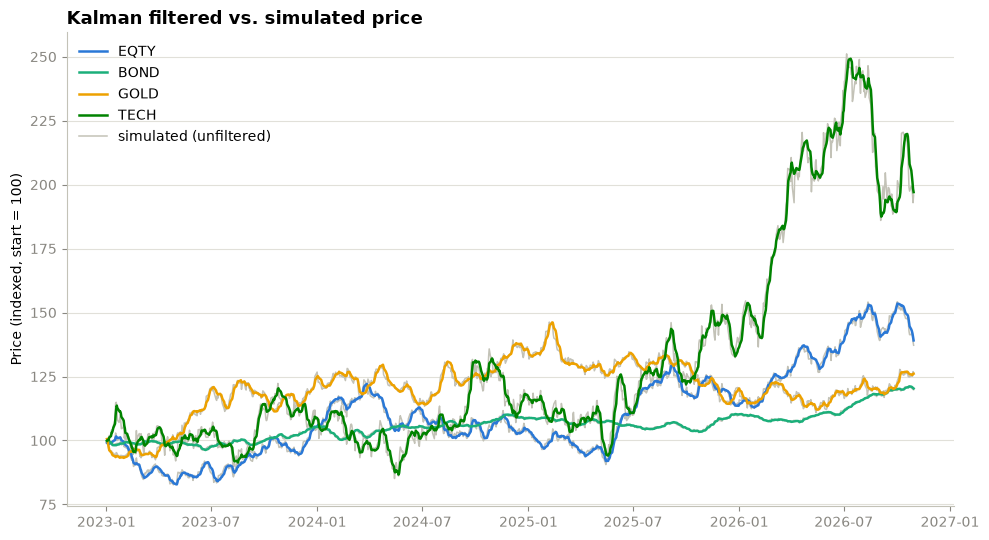

In [36]:
# We plot it using whatever code Claude spat out, holy

fig, ax = plt.subplots(figsize=(10, 5.5))

for ticker, color in zip(prices.columns, COLORS):
    ax.plot(prices.index, prices[ticker], color="#c3c2b7", linewidth=1.1, zorder=1)
    ax.plot(prices.index, filtered[ticker].price, color=color, linewidth=1.8, label=ticker, zorder=2)

ax.plot([], [], color="#c3c2b7", linewidth=1.1, label="simulated (unfiltered)")

ax.set_title("Kalman filtered vs. simulated price", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Price (indexed, start = 100)")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")

ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#898781")

ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

### Testing on real data

The filter tracks the simulated series reasonably well, so now let's see how it holds up on actual market data instead of a known ground truth.

We pick one real ETF per simulated asset class, as a rough analogue:

| Simulated | Real ETF | Description                  |
|-----------|----------|-------------------------------|
| EQTY      | SPY      | S&P 500                       |
| BOND      | TLT      | long-term US treasuries       |
| GOLD      | GLD      | gold                           |
| TECH      | QQQ      | Nasdaq-100      |

Same Q/R as before, just to check behaviour of filter

In [37]:
# yahooooooo finance
real_tickers = ["SPY", "TLT", "GLD", "QQQ"]

real_prices = yf.download(real_tickers, period="6mo", progress=False)["Close"]
real_prices = real_prices[real_tickers]
real_prices.head()

Ticker,SPY,TLT,GLD,QQQ
Date,,,,
2026-01-13,690.102600,85.872726,421.630005,624.764771
2026-01-14,686.710632,86.371422,425.940002,618.090515
2026-01-15,688.580688,86.351852,423.329987,620.315308
2026-01-16,688.003723,85.853180,421.290009,619.796509
2026-01-20,673.998169,84.728676,437.230011,606.627625


In [38]:
# Same noise as the simulated-data pass
real_filtered = {
    ticker: run_kalman(real_prices[ticker].values, noise)
    for ticker in real_prices.columns
}

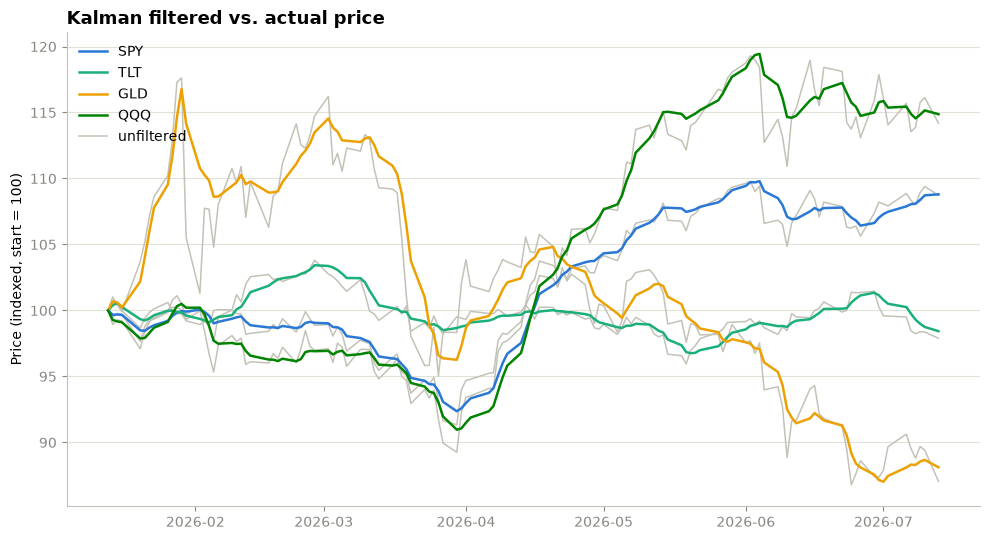

In [39]:
# The real tickers trade on very different prices (SPY/QQQ ~$750, TLT ~$85, GLD ~$370),
# so we index everything to 100 at t0 to put them on one shared axis
base = real_prices.iloc[0]
real_indexed = real_prices.div(base) * 100
real_filtered_indexed = {
    ticker: real_filtered[ticker].price / base[ticker] * 100
    for ticker in real_prices.columns
}

# whatever this is that claude churned out to display it
fig, ax = plt.subplots(figsize=(10, 5.5))

for ticker, color in zip(real_prices.columns, COLORS):
    ax.plot(real_indexed.index, real_indexed[ticker], color="#c3c2b7", linewidth=1.1, zorder=1)
    ax.plot(real_indexed.index, real_filtered_indexed[ticker], color=color, linewidth=1.8, label=ticker, zorder=2)

ax.plot([], [], color="#c3c2b7", linewidth=1.1, label="unfiltered")

ax.set_title("Kalman filtered vs. actual price", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Price (indexed, start = 100)")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")

ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#898781")

ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

**Success**, we have achieved a filtered price signal.

Now on to the next part, where we tune the Kalman filter and apply it to certain stocks, and detect market regimes.